# 🎥 Video 05: Physicochemical Properties & Molecular Descriptors
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 2 — Molecular Properties (Topics 08, 10, 11, 12)
* **Target Audience:** Cheminformatics Engineers, Medicinal Chemists, ML/AI Engineers

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 05:00** | What are Molecular Descriptors? 1D vs 2D vs 3D Properties
* **05:00 - 10:00** | The Core Physicochemical Profile: MW, MolLogP, TPSA, HBD, HBA, RotBonds
* **10:00 - 14:30** | Advanced Descriptors: Fraction Csp3, Ring Counts, LabuteASA, BertzCT Complexity
* **14:30 - 19:30** | Batch Descriptor Calculation: The `Descriptors._descList` Pipeline
* **19:30 - 24:30** | Statistical Distribution Analysis: Histograms, Boxplots & Outliers
* **24:30 - 28:00** | Live Coding: Building a SMILES -> Features -> CSV Pipeline
* **28:00 - 30:00** | Hands-On Exercise & Key Takeaways

---

### 🎯 Learning Objectives
1. Understand the physical meaning of LogP (lipophilicity), TPSA (permeability), and Rotatable Bonds (flexibility).
2. Calculate individual properties using `rdkit.Chem.Descriptors` and `rdMolDescriptors`.
3. Compute all ~200 RDKit 2D descriptors in an automated batch pipeline.
4. Clean and convert descriptor matrices into Pandas DataFrames for Machine Learning.
5. Visualize chemical property distributions and detect structural outliers.

In [1]:
# Step 0: Imports and Environment Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. What are Molecular Descriptors?
A **molecular descriptor** is a numerical value that quantifies a physical, chemical, or topological feature of a molecule:
* **1D Descriptors:** Molecular weight, atom counts, molecular formula.
* **2D Descriptors:** LogP (Wildman-Crippen), Topological Polar Surface Area (TPSA), number of rotatable bonds, ring counts, shape indices.
* **3D Descriptors:** Solvent-accessible surface area, dipole moment, volume, radius of gyration (requires 3D conformers).

These descriptors form the feature foundation for **Quantitative Structure-Activity Relationship (QSAR)** modeling and **ADMET** (Absorption, Distribution, Metabolism, Excretion, Toxicity) prediction!

In [2]:
# Let's inspect the core properties of Imatinib (Gleevec)
imatinib_smi = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"
mol = Chem.MolFromSmiles(imatinib_smi)

mw = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
hbd = Descriptors.NumHDonors(mol)
hba = Descriptors.NumHAcceptors(mol)
rot_bonds = Descriptors.NumRotatableBonds(mol)
heavy_atoms = mol.GetNumHeavyAtoms()

print(f"=== PHYSICOCHEMICAL PROFILE: IMATINIB ===")
print(f"  Molecular Weight (MW):    {mw:.2f} Da")
print(f"  Wildman-Crippen LogP:     {logp:.2f}")
print(f"  Topological Polar Area:   {tpsa:.2f} Å²")
print(f"  H-Bond Donors (HBD):      {hbd}")
print(f"  H-Bond Acceptors (HBA):   {hba}")
print(f"  Rotatable Bonds:          {rot_bonds}")
print(f"  Heavy Atom Count:         {heavy_atoms}")

=== PHYSICOCHEMICAL PROFILE: IMATINIB ===
  Molecular Weight (MW):    493.62 Da
  Wildman-Crippen LogP:     4.59
  Topological Polar Area:   86.28 Å²
  H-Bond Donors (HBD):      2
  H-Bond Acceptors (HBA):   7
  Rotatable Bonds:          7
  Heavy Atom Count:         37


## 2. Advanced Structural & Complexity Descriptors
Beyond basic Lipinski properties, modern medicinal chemistry relies heavily on:
* **Fraction Csp3 (`FractionCSP3`):** Ratio of $sp^3$ hybridized carbons to total carbons. Higher Csp3 correlates with clinical trial success, better solubility, and 3D complexity ("Escape from Flatland").
* **BertzCT (`BertzCT`):** Topological index of molecular complexity.
* **LabuteASA (`LabuteASA`):** Approximate surface area.
* **Ring Counts:** Saturated, aliphatic, and aromatic ring systems.

In [3]:
f_csp3 = Descriptors.FractionCSP3(mol)
bertz_ct = Descriptors.BertzCT(mol)
num_rings = rdMolDescriptors.CalcNumRings(mol)
num_aromatic_rings = rdMolDescriptors.CalcNumAromaticRings(mol)
num_aliphatic_rings = rdMolDescriptors.CalcNumAliphaticRings(mol)

print(f"=== ADVANCED STRUCTURAL DESCRIPTORS ===")
print(f"  Fraction Csp3:            {f_csp3:.3f}")
print(f"  Bertz Complexity Index:   {bertz_ct:.2f}")
print(f"  Total Rings:              {num_rings}")
print(f"  Aromatic Rings:           {num_aromatic_rings}")
print(f"  Aliphatic Rings:          {num_aliphatic_rings}")

=== ADVANCED STRUCTURAL DESCRIPTORS ===
  Fraction Csp3:            0.241
  Bertz Complexity Index:   1350.56
  Total Rings:              5
  Aromatic Rings:           4
  Aliphatic Rings:          1


## 3. High-Throughput Batch Descriptor Pipeline
RDKit provides ~210 pre-implemented descriptors in `rdkit.Chem.Descriptors._descList`.
Let's build an automated function that computes a selected or complete descriptor matrix for any list of molecules!

In [4]:
# Define our target descriptor calculation function
def calculate_descriptors_dataframe(smiles_series, names_series=None):
    """
    Converts a pandas Series of SMILES into a full physicochemical descriptor DataFrame.
    """
    records = []
    
    for idx, smi in enumerate(smiles_series):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
            
        record = {
            "SMILES": smi,
            "Name": names_series.iloc[idx] if names_series is not None else f"Mol_{idx+1}",
            "MW": Descriptors.MolWt(mol),
            "LogP": Descriptors.MolLogP(mol),
            "TPSA": Descriptors.TPSA(mol),
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol),
            "RotatableBonds": Descriptors.NumRotatableBonds(mol),
            "HeavyAtoms": mol.GetNumHeavyAtoms(),
            "FractionCSP3": Descriptors.FractionCSP3(mol),
            "NumRings": rdMolDescriptors.CalcNumRings(mol),
            "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "BertzCT": Descriptors.BertzCT(mol)
        }
        records.append(record)
        
    return pd.DataFrame(records)

## 4. Profiling a Real Drug Dataset
Let's load the ChEMBL EGFR compound dataset and calculate descriptor distributions.

In [5]:
# Load real dataset
candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = None
for p in candidate_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path:
    df_raw = pd.read_csv(csv_path).head(100) # Sample 100 for fast demonstration
    df_desc = calculate_descriptors_dataframe(df_raw["smiles"], df_raw["molecule_chembl_id"])
    print(f"✅ Successfully calculated descriptors for {len(df_desc)} compounds from {csv_path}!")
    display(df_desc.head())
else:
    print("Dataset path not found. Please verify datasets/ directory.")

✅ Successfully calculated descriptors for 100 compounds from ../../datasets/EGFR_compounds.csv!


,SMILES,Name,MW,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtoms,FractionCSP3,NumRings,AromaticRings,BertzCT
0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,CHEMBL63786,350.219,5.2891,37.81,1,3,2,22,0.000000,4,4,981.946165
1,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,CHEMBL53711,344.216,3.5969,53.94,1,5,3,21,0.133333,3,3,787.870918
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,CHEMBL35820,388.265,4.9333,56.27,1,5,6,24,0.222222,3,3,854.786639
3,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,CHEMBL53753,330.189,3.5726,62.73,2,5,3,20,0.071429,3,3,759.390370
4,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,CHEMBL66031,340.184,4.0122,66.49,2,4,2,21,0.000000,4,4,947.021554


## 5. Statistical Distribution Analysis & Outlier Detection
Let's visualize the property distributions using histograms and kernel density estimation (KDE).

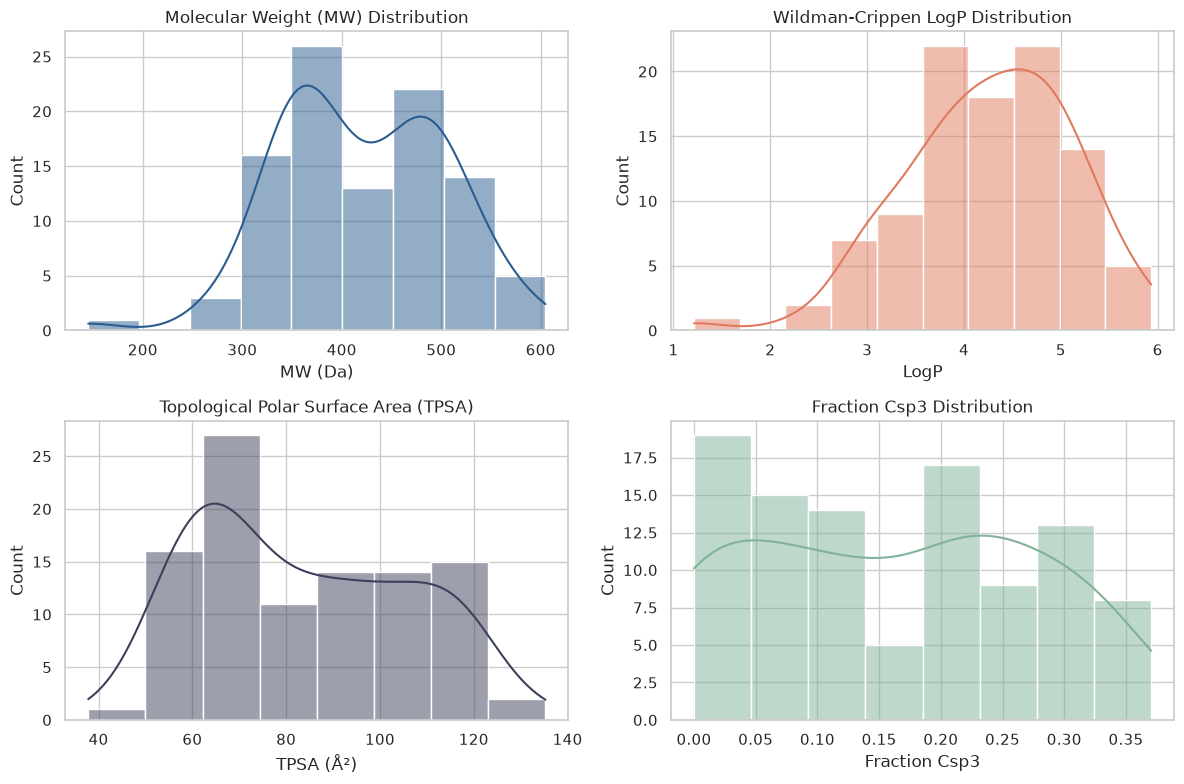

In [6]:
# Plot 4 key property distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_desc["MW"], kde=True, ax=axes[0, 0], color="#2b5c8f")
axes[0, 0].set_title("Molecular Weight (MW) Distribution")
axes[0, 0].set_xlabel("MW (Da)")

sns.histplot(df_desc["LogP"], kde=True, ax=axes[0, 1], color="#e07a5f")
axes[0, 1].set_title("Wildman-Crippen LogP Distribution")
axes[0, 1].set_xlabel("LogP")

sns.histplot(df_desc["TPSA"], kde=True, ax=axes[1, 0], color="#3d405b")
axes[1, 0].set_title("Topological Polar Surface Area (TPSA)")
axes[1, 0].set_xlabel("TPSA (Å²)")

sns.histplot(df_desc["FractionCSP3"], kde=True, ax=axes[1, 1], color="#81b29a")
axes[1, 1].set_title("Fraction Csp3 Distribution")
axes[1, 1].set_xlabel("Fraction Csp3")

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap
Let's see how properties correlate with one another (e.g. MW vs TPSA vs Heavy Atoms).

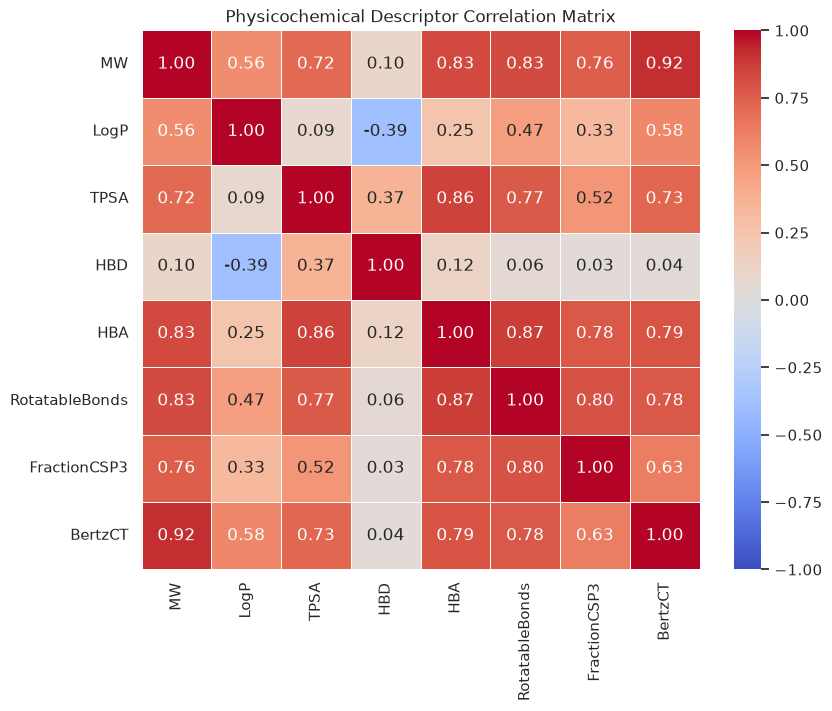

In [7]:
# Correlation matrix
numeric_cols = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds", "FractionCSP3", "BertzCT"]
corr = df_desc[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Physicochemical Descriptor Correlation Matrix")
plt.show()

## 7. 🎯 Video Hands-On Challenge & Solution
### Problem:
1. Filter the dataset to find all compounds that have:
   * `MW < 450`
   * `LogP < 4.0`
   * `FractionCSP3 > 0.25`
2. Identify the top 3 most structurally complex molecules according to `BertzCT`.
3. Display their names, properties, and 2D structures.

Found 0 compounds meeting the stringent lead-like criteria!

Top 3 Most Complex Compounds (BertzCT):


,Name,MW,LogP,BertzCT,NumRings
53,CHEMBL2029438,604.715,5.37900,1705.194706,6
58,CHEMBL2029436,590.688,5.38340,1687.956569,6
13,CHEMBL180022,557.054,5.93248,1567.756239,4


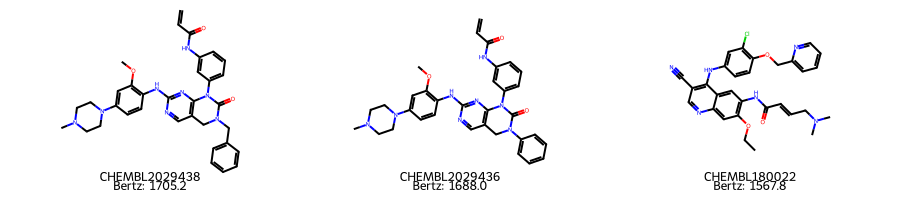

In [8]:
# 1. Filter criteria
filtered_df = df_desc[
    (df_desc["MW"] < 450) & 
    (df_desc["LogP"] < 4.0) & 
    (df_desc["FractionCSP3"] > 0.25)
]

print(f"Found {len(filtered_df)} compounds meeting the stringent lead-like criteria!")

# 2. Top 3 most complex
top_complex = df_desc.sort_values(by="BertzCT", ascending=False).head(3)
print("\nTop 3 Most Complex Compounds (BertzCT):")
display(top_complex[["Name", "MW", "LogP", "BertzCT", "NumRings"]])

# 3. Draw structures
top_mols = [Chem.MolFromSmiles(s) for s in top_complex["SMILES"]]
top_legends = [f"{row['Name']}\nBertz: {row['BertzCT']:.1f}" for _, row in top_complex.iterrows()]
Draw.MolsToGridImage(top_mols, legends=top_legends, molsPerRow=3, subImgSize=(300, 200))

## 8. Summary & Key Takeaways
* **`Descriptors.MolWt`, `MolLogP`, `TPSA`, `NumHDonors`, `NumHAcceptors`** form the bedrock of drug property calculations.
* **Fraction Csp3** reflects three-dimensionality and saturation — critical for solubility and target selectivity.
* **Correlations:** MW and Heavy Atoms are strongly collinear; LogP and TPSA often show inverse relationships.
* Automated descriptor pipelines allow effortless feature generation for downstream machine learning.

**Next Up in Video 06:** **Drug-Likeness Rules & MedChem Filters** — Lipinski's Rule of 5, Veber's criteria, and filtering toxicophores with PAINS and Brenk alerts!